Develop a program to calculate histogram and make histogram
equalization for given images. Test the program on suitable images.
Display histogram plots of the original and equalized images.

히스토그램을 계산하고 만드는 프로그램을 짜세요.
주어진 이미지로 평활화가 가능해야 합니다.
적절한 이미지를 사용하세요.
오리지널 이미지와 평활화된 이미지의 히스토그램을 출력하세요

히스토그램! 영상처리의 알파이자 오메가 정말 재밌습니다.   
히스토그램이라는 말을 처음 들어봤을 수 있겠지만 별거 없습니다.  
도수분포표를 막대 그래프로 표현한거거든요 무슨 말인지, 무엇을 해야하는지 차근차근 알아 가봅시다.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

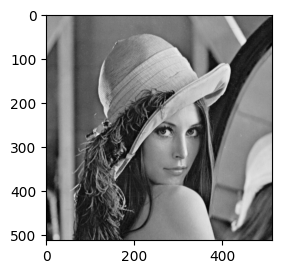

In [7]:
from matplotlib.pyplot import gray


img = cv2.imread('../Lenna.png')
img =cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.subplot(1,2,1)
plt.imshow(img)

plt.subplot(1,2,2)
plt.imshow(gray,cmap='gray')
plt.show()

In [3]:
print(img.shape)   
print(gray.shape)


(512, 512, 3)
(512, 512)


영상처리를 한다면 누구나 한 번쯤은 봤을 레나입니다. 못봤다면 앞으로 계속 신세를 질 예정입니다.  
우리가 보는 일반적인 컬러 영상은 R G B로 이루어진 3채널, 흑백 영상은 1개의 채널로 되있습니다.
각각의 채널은 0에서 255의 범위를 갖죠. 256 = 2^8 8비트입니다. 처음에 8비트라는 단어를 들었을때 무슨 소린가 싶었는데  
바로 이해가 되죠? 흑백사진(GRAY SCALE)을 기준으로 이미지는 바둑판처럼 격자를 나눠 배열에 저장되고,  
(8비트 기준)각 배열 원소(픽셀)는 0-255의 값을 갖습니다. 0에 가까울 수록 검정, 255에 가까울 수록 하양에 가깝죠.  
그럼 예제를 한 번 볼까요?

(array([1.1500e+02, 6.3500e+02, 2.5940e+03, 4.6990e+03, 7.2870e+03,
        1.0332e+04, 7.1860e+03, 6.7810e+03, 3.7890e+03, 3.2490e+03,
        4.0680e+03, 3.5100e+03, 4.6050e+03, 3.8420e+03, 4.3330e+03,
        6.6700e+03, 7.3840e+03, 9.3800e+03, 6.2800e+03, 5.4170e+03,
        6.9970e+03, 6.5200e+03, 1.0184e+04, 9.5170e+03, 8.6260e+03,
        9.8190e+03, 9.3440e+03, 1.1706e+04, 9.1630e+03, 1.0728e+04,
        1.1121e+04, 6.2940e+03, 6.2050e+03, 5.0460e+03, 4.6540e+03,
        4.1440e+03, 2.5610e+03, 3.6620e+03, 3.7420e+03, 3.4430e+03,
        4.5010e+03, 4.1520e+03, 4.4560e+03, 1.8090e+03, 1.1300e+03,
        3.3600e+02, 1.0100e+02, 2.2000e+01, 1.0000e+00, 4.0000e+00]),
 array([ 25. ,  29.4,  33.8,  38.2,  42.6,  47. ,  51.4,  55.8,  60.2,
         64.6,  69. ,  73.4,  77.8,  82.2,  86.6,  91. ,  95.4,  99.8,
        104.2, 108.6, 113. , 117.4, 121.8, 126.2, 130.6, 135. , 139.4,
        143.8, 148.2, 152.6, 157. , 161.4, 165.8, 170.2, 174.6, 179. ,
        183.4, 187.8, 192.2, 196.6

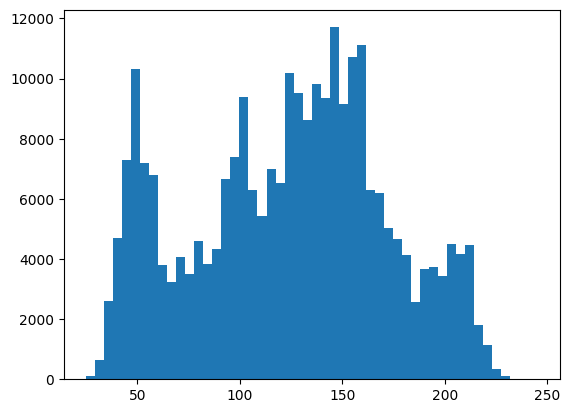

In [4]:
flat_gray = gray.flatten()
plt.hist(flat_gray,bins=50)

레나의 픽셀이 분포도를 표현한  그려진 히스토그램이 완성 되었습니다!  
그래프가 Y축으로 12000 까지 있는 이유는 이미지 사이즈가 512*512이기 때문입니다.  
262,144개의 픽셀이 이 한 이미지에 존재 하는것이죠.  
그렇다면 3채널의 rgb가 있는 이미지는 어떨지 한 번 볼까요?


(array([1.1500e+02, 6.3500e+02, 2.5940e+03, 4.6990e+03, 7.2870e+03,
        1.0332e+04, 7.1860e+03, 6.7810e+03, 3.7890e+03, 3.2490e+03,
        4.0680e+03, 3.5100e+03, 4.6050e+03, 3.8420e+03, 4.3330e+03,
        6.6700e+03, 7.3840e+03, 9.3800e+03, 6.2800e+03, 5.4170e+03,
        6.9970e+03, 6.5200e+03, 1.0184e+04, 9.5170e+03, 8.6260e+03,
        9.8190e+03, 9.3440e+03, 1.1706e+04, 9.1630e+03, 1.0728e+04,
        1.1121e+04, 6.2940e+03, 6.2050e+03, 5.0460e+03, 4.6540e+03,
        4.1440e+03, 2.5610e+03, 3.6620e+03, 3.7420e+03, 3.4430e+03,
        4.5010e+03, 4.1520e+03, 4.4560e+03, 1.8090e+03, 1.1300e+03,
        3.3600e+02, 1.0100e+02, 2.2000e+01, 1.0000e+00, 4.0000e+00]),
 array([ 25. ,  29.4,  33.8,  38.2,  42.6,  47. ,  51.4,  55.8,  60.2,
         64.6,  69. ,  73.4,  77.8,  82.2,  86.6,  91. ,  95.4,  99.8,
        104.2, 108.6, 113. , 117.4, 121.8, 126.2, 130.6, 135. , 139.4,
        143.8, 148.2, 152.6, 157. , 161.4, 165.8, 170.2, 174.6, 179. ,
        183.4, 187.8, 192.2, 196.6

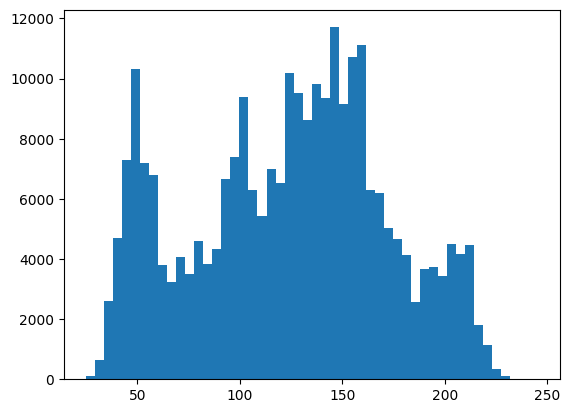

In [5]:
flat = gray.flatten()
plt.hist(flat,bins=50)

RGB 3개의 채널이 존재하는 레나의 픽셀이 분포 되어있는 히스토그램이 완성 되었습니다.  
보시다시피 분포도가 Y축으로 대략 3배정도 증가한걸 알 수 있습니다.
채널이 3배로 증가했는데 히스토그램이 비슷하게 생겼죠?  
근데 왜 똑같이 생기지 않았냐  의문이 생길 수 있습니다.  
그 이유는 RGB를 Grayscale로 변환하는 공식이  
$Y=0.299*R+0.587*G+0.114*B$ 이기 때문입니다. 사람눈이 저정도 비율로 RGB를 인식하기 때문이에요.

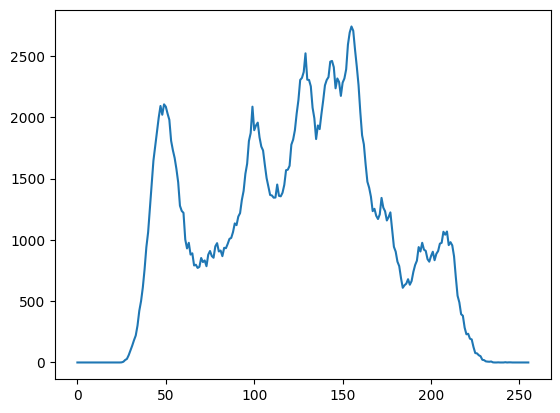

In [12]:
#hstack:horizonal stack 3차원부턴 층으로 쌓아줌
#vstack:vertical stack  3차원부턴 행 방향으로 쌓아줌
#column_stack:same as hstack after 2D 1차원일땐 열방향으로 합쳐줌
def get_histogram(image, bins):
    # array with size of bins, set to zeros
    histogram = np.zeros(bins)
    
    # loop through pixels and sum up counts of pixels
    for pixel in image:
        histogram[pixel] += 1
    
    # return our final result
    return histogram

hist = get_histogram(flat, 256)
plt.plot(hist)


히스토그램 공식
$\displaystyle P_x(j) = \sum_{i=0}^{j}P_x(i)$ 을 그대로 모든 픽셀에 적용해서 그려보면 위와 비슷한 수치가 나오는걸 알 수 있습니다.  
이제 픽셀들을 합하는 함수를 한 번 간단히 구현 해보겠습니다.


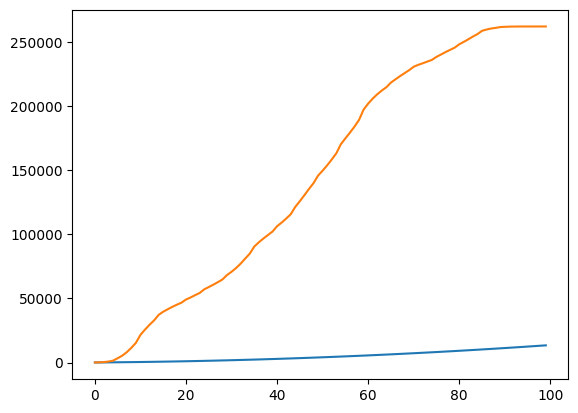

In [7]:
# create our cumulative sum function
def cumsum(a):
    a = iter(a)
    b = [next(a)]
    for i in a:
        b.append(b[-1] + i)
    return np.array(b)

# execute the fn
cs = cumsum(hist)

# display the result
plt.plot(cs)

$\displaystyle s_k = \sum_{j=0}^{k} {\frac{n_j}{N}}$ 이 공식은 다시 합계 값을 0에서 255로 지정했을 때 나오는 결과입니다.

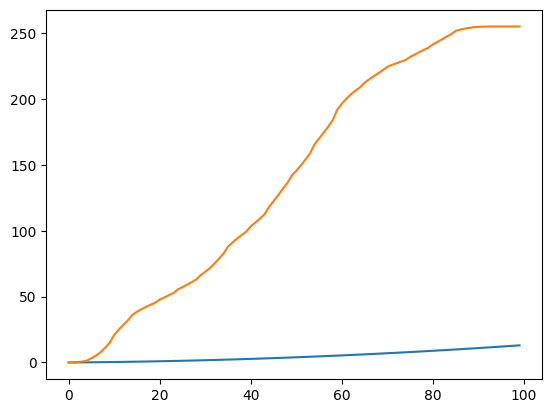

In [8]:
# re-normalize cumsum values to be between 0-255

# numerator & denomenator
nj = (cs - cs.min()) * 255
N = cs.max() - cs.min()

# re-normalize the cdf
cs = nj / N

plt.plot(cs)

이미지를 이대로 쓰면 소수점때문에 표현이 안되니 int형으로 다시 바꿔보겠습니다.  
uint는 unsigned int로 자연수라 생각하시면 됩니다.  
결과값을 보면 그래프가 조금 거칠어진걸 확인할 수 있습니다.

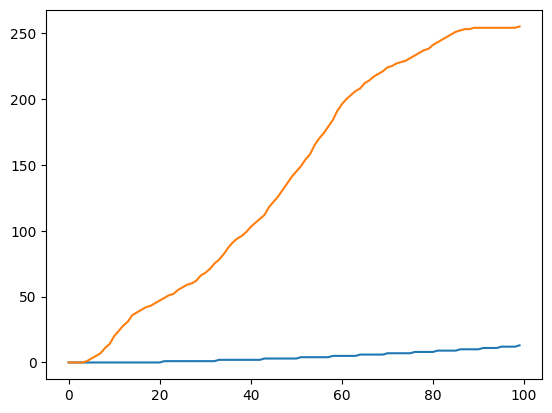

In [9]:
# cast it back to uint8 since we can't use floating point values in imgs
cs = cs.astype('uint8')

plt.plot(cs)

Cool, now we know the fundamental concept of image and the histogram!  
It is time to learn histogram equalization.  
![nn](histogram_equalization.png)  

source:wikipedia  

You don't have to be afraid. It's a simple algorithm.

$H'(v)=round(\frac{cdf(v)-cdf{min}}{(M*N)-cdf_{min}}*(L-1))$  
this is the essence of formula, let's see what is these factors exactly do  
$ cdf(v): 히스토그램 누적 함수
cdf_{min}: 누적 최소 값, 1
M*N : 픽셀 수, 폭x높이
L : 분포영역, 256 
round(v) : 반올림  
H′(v): 이퀄라이즈된 히스토그램 값 $ 

NameError: name 'img_new' is not defined

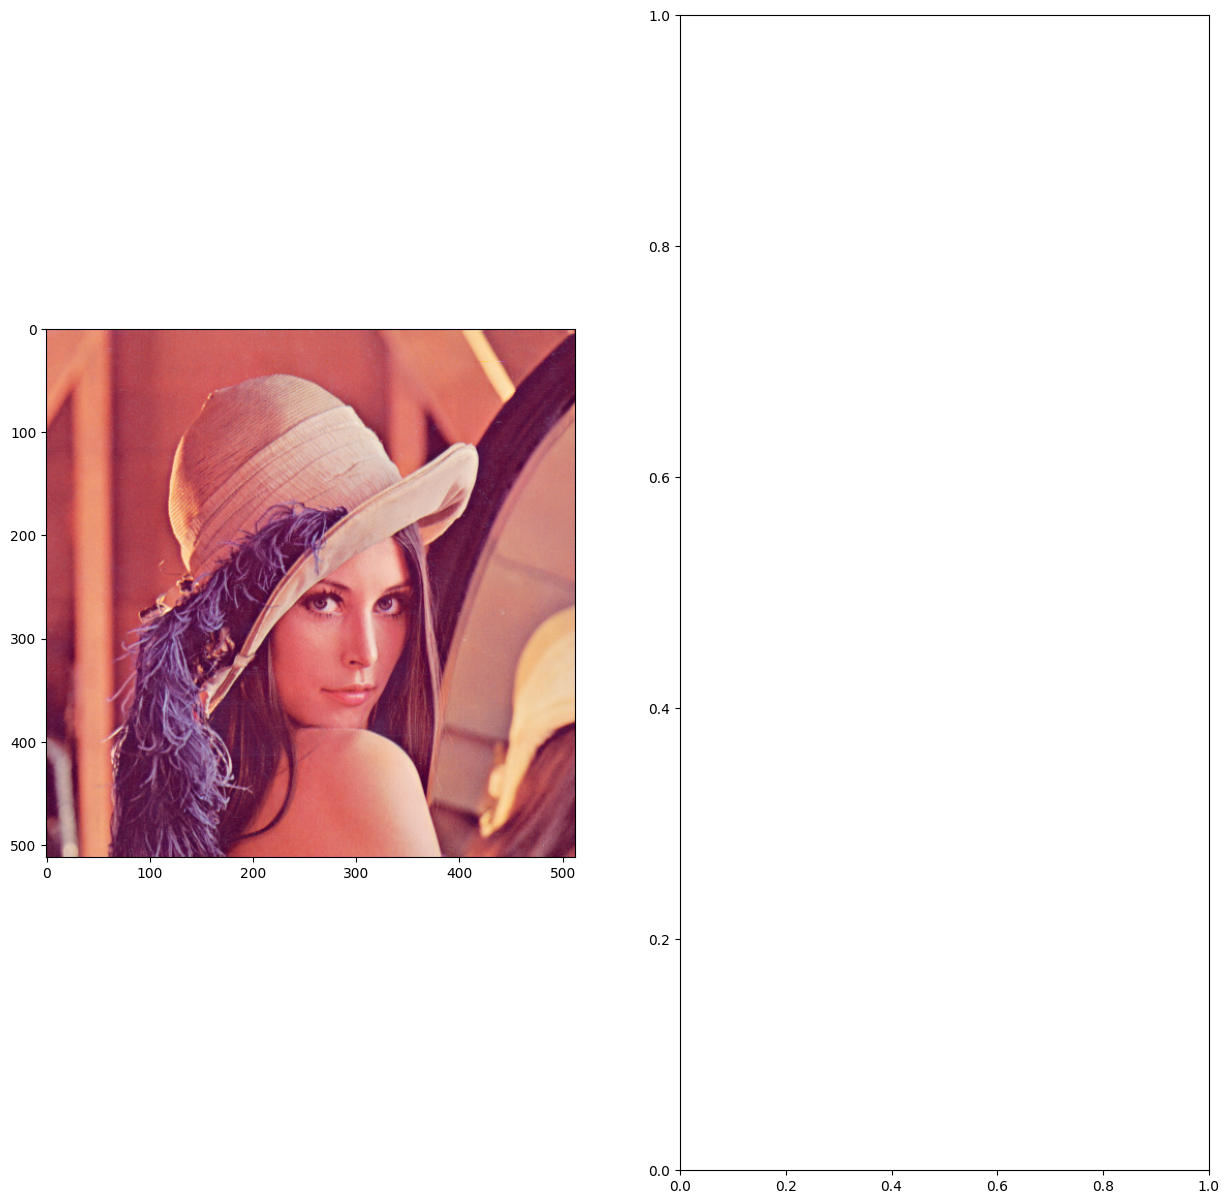

In [10]:
# set up side-by-side image display
fig = plt.figure()
fig.set_figheight(15)
fig.set_figwidth(15)

fig.add_subplot(1,2,1)
plt.imshow(img, cmap='gray')

# display the stretched image
fig.add_subplot(1,2,2)
plt.imshow(img_new, cmap='gray')

plt.show(block=True)